In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [35]:
df = pd.read_csv("student_lifestyle_performance_dataset.csv")
df.describe()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


In [24]:
#Usamos OneHotEncoder para convertir las variables categoricas en variables numericas
#Y despues procesarlas para ver si son utiles
categorical_cols = ["Branch", "Diet_Type", "Residence"]
numerical_cols = [col for col in df.columns if col not in categorical_cols]
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
column_transformer = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)],remainder='passthrough')
X_encoded = column_transformer.fit_transform(df)
encoded_col_names = column_transformer.named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_columns = list(encoded_col_names) + numerical_cols
df_encoded = pd.DataFrame(X_encoded, columns=final_columns)
print(df_encoded.head())

   Branch_Civil  Branch_ECE  Branch_Electrical  Branch_IT  Branch_Mechanical  \
0           0.0         1.0                0.0        0.0                0.0   
1           1.0         0.0                0.0        0.0                0.0   
2           0.0         0.0                1.0        0.0                0.0   
3           0.0         0.0                0.0        0.0                0.0   
4           1.0         0.0                0.0        0.0                0.0   

   Diet_Type_Veg  Residence_Hosteller   Age  Study_Hours_per_Day  Sleep_Hours  \
0            0.0                  1.0  23.0                 4.14         6.84   
1            1.0                  0.0  20.0                 5.97         5.52   
2            1.0                  1.0  24.0                 3.19         3.39   
3            0.0                  0.0  21.0                 4.77         6.44   
4            1.0                  0.0  23.0                 5.42         6.54   

   Screen_Time_Hours  Gym_Hours_

In [ ]:
#Seleccionamos las variables que creemos que pueden tener una relacion importante con la variable objetivo y las separamos en X e y
var_cols = ["Branch_Civil", "Branch_ECE", "Branch_Electrical", "Branch_IT", "Branch_Mechanical", "Diet_Type_Veg", "Residence_Hosteller", "Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week", "Attendance_Percentage", "Stress_Level_1_to_10","CGPA"]
X = df_encoded[var_cols]
Y = df_encoded["Internal_Marks"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [27]:
C=1e3
svr_lin = SVR(kernel="linear", C=C)
svr_rbf = SVR(kernel="rbf", C=C, gamma=0.1)
svr_pol = SVR(kernel="poly", C=C, degree=3)

In [77]:
model1 = svr_lin.fit(X_train,y_train)
model2 = svr_rbf.fit(X_train,y_train)
model3 = svr_pol.fit(X_train,y_train)

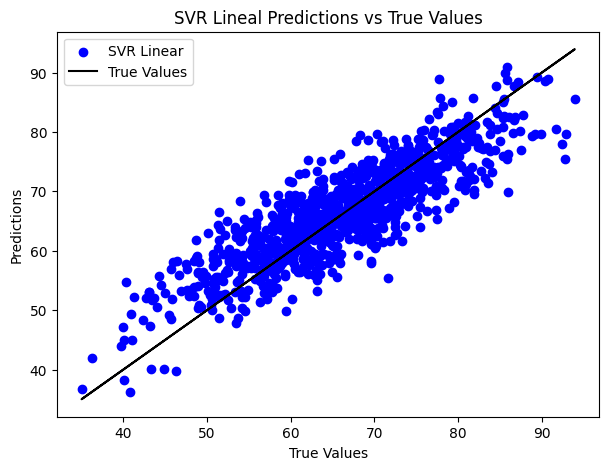

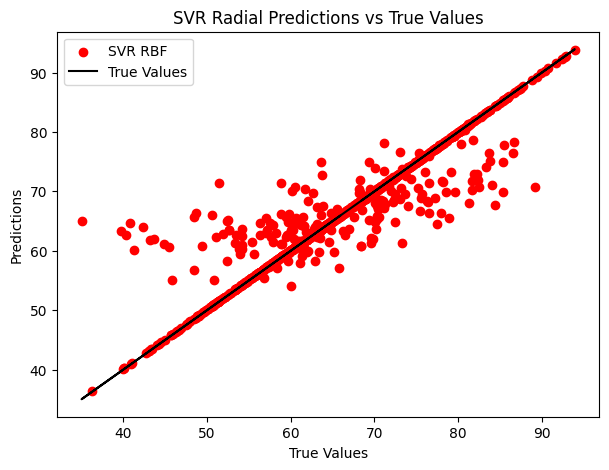

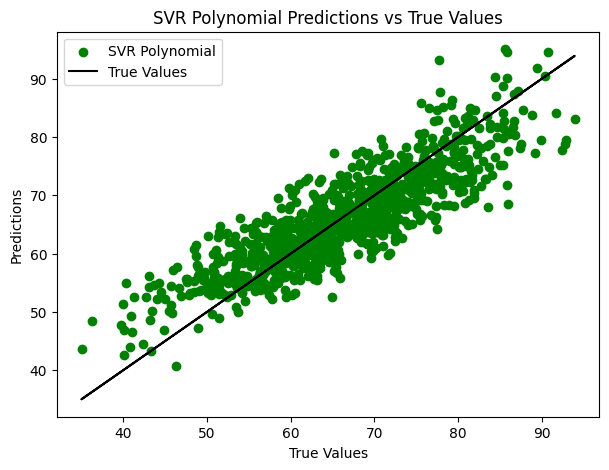

In [91]:
plt.figure(figsize=(7,5))
plt.scatter(Y, model1.predict(X), color='blue', label='SVR Linear')
plt.plot(Y, Y, color='black', label='True Values')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('SVR Lineal Predictions vs True Values')
plt.legend()
plt.figure(figsize=(7,5))
plt.scatter(Y, model2.predict(X), color='red', label='SVR RBF')
plt.plot(Y, Y, color='black', label='True Values')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('SVR Radial Predictions vs True Values')
plt.legend()
plt.figure(figsize=(7,5))
plt.scatter(Y, model3.predict(X), color='green', label='SVR Polynomial')
plt.plot(Y, Y, color='black', label='True Values')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('SVR Polynomial Predictions vs True Values')
plt.legend()

In [95]:
# metricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
y_predict = model1.predict(X_test)
print("SVR Lineal")
print("MSE:", mean_squared_error(y_test, y_predict))
print("RMSE:", root_mean_squared_error(y_test, y_predict))
print("MAE:", mean_absolute_error(y_test, y_predict))
print("R2:", r2_score(y_test, y_predict))
y_predict = model2.predict(X_test)
print("SVR RBF")
print("MSE:", mean_squared_error(y_test, y_predict))
print("RMSE:", root_mean_squared_error(y_test, y_predict))
print("MAE:", mean_absolute_error(y_test, y_predict))
print("R2:", r2_score(y_test, y_predict))
y_predict = model3.predict(X_test)
print("SVR Polinomial")
print("MSE:", mean_squared_error(y_test, y_predict))
print("RMSE:", root_mean_squared_error(y_test, y_predict))
print("MAE:", mean_absolute_error(y_test, y_predict))
print("R2:", r2_score(y_test, y_predict))

SVR Lineal
MSE: 30.747781204664967
RMSE: 5.545068187557748
MAE: 4.459005114295204
R2: 0.7379358793788378
SVR RBF
MSE: 69.59945858064077
RMSE: 8.342628996943397
MAE: 6.446950372315329
R2: 0.40680204573989276
SVR Polinomial
MSE: 30.469080462076853
RMSE: 5.519880475343362
MAE: 4.4397517693409245
R2: 0.7403112528907234


In [99]:
df_encoded["prediction"] = model2.predict(X)

df_encoded[["Internal_Marks", "prediction"]].sample(10)

,Internal_Marks,prediction
451,63.10,62.329659
959,69.31,74.958443
943,77.33,77.229754
751,61.43,61.329883
972,85.92,85.820395
37,58.05,58.149936
394,70.23,70.129897
303,69.40,69.499973
935,70.96,71.060130
996,66.97,67.069910
